# AttentionEncoder (NO LTN) — attention encoder + KAN, standard loss

Same architecture as `AttentionEncoder.ipynb` (`FeatureAttentionEncoder` -> KAN),
but **without the Logic Tensor Network**. Trained with ordinary
`CrossEntropyLoss` on the logits, so:

- there is **no satisfaction (`sat`) term** anywhere,
- we still report **accuracy** and the **reliable_score** (hierarchical soft
  metric: full credit for exact match, 0.5 if the L1/MQTT-vs-Benign level is
  correct).

This is the "KAN + attention, no logic" ablation row (Reviewer 2.3): it
isolates the contribution of the logic layer by removing it while keeping the
encoder and KAN identical.


In [1]:
# --- imports & paths (NO ltn import) ---
import os, sys, time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('../P1_structurelevel'))

from utils import MultiKANModel, DataLoader
from attention_modules import AttentionKANModel, FeatureAttentionEncoder
from kan import KAN

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


In [2]:
# --- Config ---
TRAIN_PATH = '../P1_structurelevel/efficiency/input_files/logiKNet_train_10000.csv'
TEST_PATH  = '../P1_structurelevel/efficiency/input_files/logiKNet_test_3994.csv'

X_columns = [
    'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate',
    'IPv', 'LLC',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
    'Magnitue', 'Radius', 'Covariance',
]
label_L2_names = {
    0: "MQTT-DDoS-Connect_Flood", 1: "MQTT-DDoS-Publish_Flood",
    2: "MQTT-DoS-Connect_Flood", 3: "MQTT-DoS-Publish_Flood",
    4: "MQTT-Malformed_Data", 5: "Benign",
}
BENIGN_L2 = 5

IN_FEATURES = len(X_columns)      # 18
N_CLASSES   = len(label_L2_names) # 6
KAN_WIDTH   = [IN_FEATURES, 6, 6, N_CLASSES]
ATTN = dict(d_model=32, n_heads=4, n_layers=2, dropout=0.1, residual=True)

SEED   = 42
EPOCHS = 2000   # safety cap only; early stopping normally ends training first
LR     = 1e-3

# FAST_DEV: train on the small 3994-row file on CPU for a quick sanity run.
FAST_DEV   = False
EVAL_EVERY = 25

SAVE_DIR = './saved'
os.makedirs(SAVE_DIR, exist_ok=True)
print('IN_FEATURES =', IN_FEATURES, '| N_CLASSES =', N_CLASSES, '| KAN_WIDTH =', KAN_WIDTH)


IN_FEATURES = 18 | N_CLASSES = 6 | KAN_WIDTH = [18, 6, 6, 6]


In [3]:
# --- 1. Read input data (label_L2 already integer 0..5; no mapping) ---
if FAST_DEV:
    train_df = pd.read_csv(TEST_PATH)
    test_df  = pd.read_csv(TEST_PATH)
    print('FAST_DEV: training on the 3994-row file (sanity check only)')
else:
    train_df = pd.read_csv(TRAIN_PATH)
    test_df  = pd.read_csv(TEST_PATH)

missing = [c for c in X_columns + ['label_L2'] if c not in train_df.columns]
assert not missing, f'missing columns: {missing}'

for d in (train_df, test_df):
    d['label_L1'] = (d['label_L2'] == BENIGN_L2).astype(int)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_df[X_columns])
test_X_scaled  = scaler.transform(test_df[X_columns])
print('train shape:', train_X_scaled.shape, '| test shape:', test_X_scaled.shape)
print('NaN train/test:', np.isnan(train_X_scaled).any(), np.isnan(test_X_scaled).any())

train_y = train_df[['label_L1', 'label_L2']].values
test_y  = test_df[['label_L1', 'label_L2']].values
print('train L2 dist:', np.bincount(train_y[:, 1]))

train_loader = DataLoader(
    data=torch.tensor(train_X_scaled, dtype=torch.float32, device=device),
    labels=torch.tensor(train_y[:, 1], dtype=torch.long, device=device),
    batch_size=len(train_df))
test_loader = DataLoader(
    data=torch.tensor(test_X_scaled, dtype=torch.float32, device=device),
    labels=torch.tensor(test_y[:, 1], dtype=torch.long, device=device),
    batch_size=len(test_df))


train shape: (10000, 18) | test shape: (3994, 18)
NaN train/test: False False
train L2 dist: [1688 1691 1700 1697 1542 1682]


In [4]:
# --- metrics (accuracy + reliable_score; NO satisfaction) ---
def compute_accuracy(loader, model):
    total_correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for data, labels in loader:
            preds = torch.argmax(model(data), dim=1)
            total_correct += (preds == labels).sum()
            total += labels.numel()
    return (total_correct.float() / total).item()


def reliable_score(loader, model):
    """Full credit for exact match; 0.5 if wrong at L2 but both are MQTT
    (label < 5), i.e. L1 level correct."""
    score = 0
    model.eval()
    with torch.no_grad():
        for data, labels in loader:
            preds = torch.argmax(model(data), dim=1)
            for i in range(len(labels)):
                if labels[i] == preds[i]:
                    score += 1
                elif labels[i] < 5 and preds[i] < 5:
                    score += 0.5
    return score / loader.batch_size


In [5]:
# --- 2. Build AttentionKANModel = FeatureAttentionEncoder -> KAN ---
torch.manual_seed(SEED)
np.random.seed(SEED)

kan = KAN(width=KAN_WIDTH, grid=5, k=3, seed=SEED, device=device)
model = AttentionKANModel(IN_FEATURES, MultiKANModel(kan), **ATTN).to(device)

with torch.no_grad():
    _logits = model(train_loader.data[:8])
print('logits shape:', tuple(_logits.shape), '(expect [8,', N_CLASSES, '])')
print('attention map shape:', tuple(model.last_attention().shape))

# standard supervised training: no LTN predicate, plain cross-entropy
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print('trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))


checkpoint directory created: ./model
saving model version 0.0
logits shape: (8, 6) (expect [8, 6 ])
attention map shape: (8, 18, 18)
trainable params: 21469


In [6]:
# --- 3. Train with CrossEntropyLoss; stop when loss converges ---
# Early stop when |loss change| < LOSS_TOL for PATIENCE consecutive epochs.
# EPOCHS stays as a safety cap. stop_epoch tells you the budget to set for
# the fixed-epoch multi-seed runs.
LOSS_TOL = 1e-3
PATIENCE = 5

hist_loss = []
stop_epoch = EPOCHS - 1
small_count = 0
for epoch in range(EPOCHS):
    model.train()
    t0 = time.time()
    optimizer.zero_grad()
    logits = model(train_loader.data, training=True)
    loss = criterion(logits, train_loader.labels)
    loss.backward()
    optimizer.step()
    step_t = time.time() - t0
    hist_loss.append(loss.item())

    if epoch % EVAL_EVERY == 0:
        print(f"epoch {epoch:4d} | CE loss {loss.item():.4f} | step {step_t*1000:.0f} ms")

    if epoch > 0:
        delta = abs(hist_loss[-1] - hist_loss[-2])
        small_count = small_count + 1 if delta < LOSS_TOL else 0
        if small_count >= PATIENCE:
            stop_epoch = epoch
            print(f"converged: |dloss| < {LOSS_TOL} for {PATIENCE} epochs, "
                  f"stopping at epoch {epoch} (loss {loss.item():.4f})")
            break

print(f"\n>>> stopped at epoch {stop_epoch} "
      f"(use ~this many epochs for the fixed multi-seed runs)")

print('\n=== final evaluation ===')
final_acc = compute_accuracy(test_loader, model)
final_rel = reliable_score(test_loader, model)
print(f"test accuracy : {final_acc:.4f}")
print(f"reliable score: {final_rel:.4f}")


epoch    0 | CE loss 1.7864 | step 1943 ms
epoch   25 | CE loss 1.6465 | step 1313 ms
epoch   50 | CE loss 1.4361 | step 1246 ms
epoch   75 | CE loss 1.2170 | step 1515 ms
epoch  100 | CE loss 1.0488 | step 1273 ms
epoch  125 | CE loss 0.9258 | step 1383 ms
epoch  150 | CE loss 0.8304 | step 1245 ms
epoch  175 | CE loss 0.7644 | step 1297 ms
epoch  200 | CE loss 0.7886 | step 1244 ms
epoch  225 | CE loss 0.6869 | step 1360 ms
epoch  250 | CE loss 0.6592 | step 1227 ms
epoch  275 | CE loss 0.6408 | step 1389 ms
epoch  300 | CE loss 0.6198 | step 1279 ms
epoch  325 | CE loss 0.6003 | step 1264 ms
epoch  350 | CE loss 0.5754 | step 1329 ms
epoch  375 | CE loss 0.5450 | step 1358 ms
epoch  400 | CE loss 0.7090 | step 1222 ms
epoch  425 | CE loss 0.6268 | step 1265 ms
epoch  450 | CE loss 0.5788 | step 1255 ms
epoch  475 | CE loss 0.5569 | step 1332 ms
epoch  500 | CE loss 0.5476 | step 1294 ms
epoch  525 | CE loss 0.5308 | step 1248 ms
epoch  550 | CE loss 0.5180 | step 1248 ms
epoch  575 

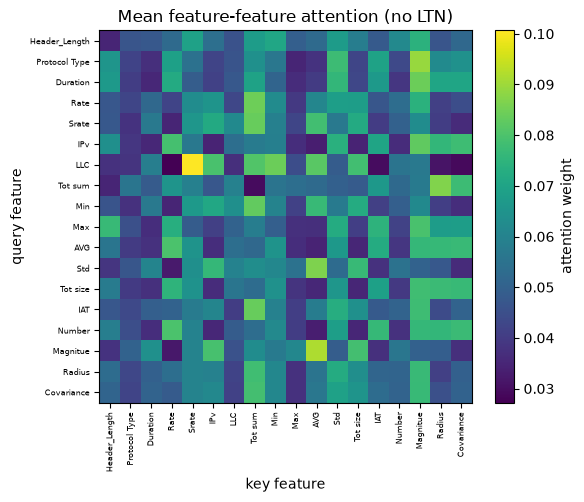

In [7]:
# --- feature-feature attention (interpretability) ---
import matplotlib.pyplot as plt
with torch.no_grad():
    _ = model(test_loader.data)
A = model.last_attention().mean(0).cpu().numpy()   # [F, F] averaged over test
plt.figure(figsize=(6, 5))
plt.imshow(A, cmap='viridis')
plt.colorbar(label='attention weight')
plt.title('Mean feature-feature attention (no LTN)')
plt.xlabel('key feature'); plt.ylabel('query feature')
plt.xticks(range(IN_FEATURES), X_columns, rotation=90, fontsize=6)
plt.yticks(range(IN_FEATURES), X_columns, fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'attention_map_noLTN.png'), dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# --- 4. Save checkpoint for evaluation (no sat metric) ---
ckpt_path = os.path.join(SAVE_DIR, 'attn_kan_noLTN_2_6.pt')
torch.save({
    'model_state': model.state_dict(),
    'config': {
        'IN_FEATURES': IN_FEATURES, 'N_CLASSES': N_CLASSES,
        'KAN_WIDTH': KAN_WIDTH, 'ATTN': ATTN, 'SEED': SEED,
        'X_columns': X_columns, 'label_L2_names': label_L2_names,
        'BENIGN_L2': BENIGN_L2,
    },
    'scaler_mean': scaler.mean_, 'scaler_scale': scaler.scale_,
    'history': {'loss': hist_loss},
    'final': {'acc': final_acc, 'reliable': final_rel},
}, ckpt_path)
print('saved checkpoint ->', ckpt_path)

# Do NOT torch.save(model, ...): pykan's Symbolic_KANLayer holds lambdas that
# cannot be pickled. Rebuild + load_state_dict to reload (see cell below).


saved checkpoint -> ./saved/attn_kan_noLTN_2_6.pt


## Reload for evaluation

```python
import torch
from utils import MultiKANModel
from attention_modules import AttentionKANModel
from kan import KAN

ckpt = torch.load('./saved/attn_kan_noLTN_2_6.pt', map_location=device)
cfg = ckpt['config']
kan = KAN(width=cfg['KAN_WIDTH'], grid=5, k=3, seed=cfg['SEED'], device=device)
model = AttentionKANModel(cfg['IN_FEATURES'], MultiKANModel(kan), **cfg['ATTN']).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
```

This is the "KAN + attention, no logic" row. Compare its accuracy /
reliable_score against the LTN version (`AttentionEncoder.ipynb`) to quantify
what the logic layer adds. For the real numbers set `FAST_DEV = False`.
